# F_S3.1 — Pearson–Spearman disagreement

This notebook identifies cases with strong Pearson correlation but weaker Spearman correlation, reports their proportion among all Pearson-selected cases, and visualizes both the metric space and representative raw scatterplots.

The primary rule uses absolute correlations so that it matches the current Simple gate:

$$|Pearson| > 0.7,\qquad |Spearman| < 0.7.$$

The literal signed rule $Pearson>0.7$ and $Spearman<0.7$ is also reported as a sensitivity analysis.

In [1]:
# ============================================================
# Configuration — edit thresholds and filters here
# ============================================================
from pathlib import Path
import json
import math
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PEARSON_THRESHOLD = 0.70
SPEARMAN_THRESHOLD = 0.70
USE_ABSOLUTE_CORRELATIONS = True   # True matches the Simple gate
E_STRENGTHS = ('strong',)
NEW_STRENGTHS = None              # None = analyze all available strengths
MIC_SUBSET_THRESHOLD = 0.80         # also report this sensitivity subset
RAW_EXAMPLES_PER_FAMILY = 3         # gap quantiles: low / median / high
MAX_RAW_EXAMPLES_PER_DATASET = 21
MAKE_RAW_GALLERY = True

def find_project_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'E').is_dir() and (candidate / 'F').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the project root containing E/ and F/.')

ROOT = find_project_root(Path.cwd())
OUT_DIR = ROOT / 'F' / 'output' / 'S3_1_pearson_spearman_disagreement'
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_SPECS = {
    'E data — strong': {
        'cases': ROOT / 'E/output/S3_snr_mic_sweep/cases.csv',
        'metrics': ROOT / 'E/output/S3_snr_mic_sweep/metrics_full.parquet',
        'points': ROOT / 'E/output/S3_snr_mic_sweep/scatter_points.npz',
        'strength_column': 'variant_level',
        'strengths': E_STRENGTHS,
        'index_column': 'candidate_index',
        'noise_column': 'inverse_snr',
        'noise_label': '1 / SNR (more noise →)',
    },
    'New data — all strengths': {
        'cases': ROOT / 'F/output/S1_parameterized/cases.csv',
        'metrics': ROOT / 'F/output/S2_metrics/metrics_full.parquet',
        'points': ROOT / 'F/output/S1_parameterized/scatter_points.npz',
        'strength_column': 'strength_name',
        'strengths': NEW_STRENGTHS,
        'index_column': None,
        'noise_column': 'snr_float',
        'noise_label': 'SNR coordinate',
    },
}

plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 180, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.22,
})

print('Project root:', ROOT)
print('Output directory:', OUT_DIR)
print(f'Primary rule: |Pearson| > {PEARSON_THRESHOLD} and |Spearman| < {SPEARMAN_THRESHOLD}')

Project root: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic
Output directory: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/S3_1_pearson_spearman_disagreement
Primary rule: |Pearson| > 0.7 and |Spearman| < 0.7


In [2]:
# ============================================================
# Load cases and metrics while preserving raw-scatter row indices
# ============================================================
def load_dataset(dataset_name, spec):
    case_columns = [
        'case_id', 'family_id', 'family_name', spec['strength_column'],
        spec['noise_column'],
    ]
    if spec['index_column'] is not None:
        case_columns.append(spec['index_column'])

    cases = pd.read_csv(spec['cases'], usecols=case_columns)
    if spec['index_column'] is None:
        # This must be assigned before filtering or merging.
        cases['scatter_point_index'] = np.arange(len(cases), dtype=np.int64)
    else:
        cases['scatter_point_index'] = cases[spec['index_column']].astype(np.int64)

    if spec['strengths'] is not None:
        strength_values = cases[spec['strength_column']].astype(str).str.lower()
        wanted = {str(v).lower() for v in spec['strengths']}
        cases = cases[strength_values.isin(wanted)].copy()
    else:
        cases = cases.copy()

    metrics = pd.read_parquet(
        spec['metrics'], columns=['case_id', 'MIC', 'pearson_r', 'spearman_rho']
    )
    if metrics['case_id'].duplicated().any():
        raise ValueError(f'{dataset_name}: duplicate case_id values in metrics.')

    data = cases.merge(metrics, on='case_id', how='inner', validate='one_to_one')
    data['dataset'] = dataset_name
    data['noise_value'] = pd.to_numeric(data[spec['noise_column']], errors='coerce')
    data['abs_pearson'] = data['pearson_r'].abs()
    data['abs_spearman'] = data['spearman_rho'].abs()

    if USE_ABSOLUTE_CORRELATIONS:
        data['pearson_value'] = data['abs_pearson']
        data['spearman_value'] = data['abs_spearman']
    else:
        data['pearson_value'] = data['pearson_r']
        data['spearman_value'] = data['spearman_rho']

    data['pearson_selected'] = data['pearson_value'] > PEARSON_THRESHOLD
    data['discordant'] = (
        data['pearson_selected']
        & (data['spearman_value'] < SPEARMAN_THRESHOLD)
    )
    data['correlation_gap'] = data['pearson_value'] - data['spearman_value']

    if len(data):
        max_index = int(data['scatter_point_index'].max())
        if max_index < 0:
            raise ValueError(f'{dataset_name}: negative scatter-point index.')

    print(
        f'{dataset_name}: {len(cases):,} selected cases, '
        f'{len(data):,} with computed metrics, '
        f'{data.family_id.nunique()} families.'
    )
    return data

datasets = {name: load_dataset(name, spec) for name, spec in DATASET_SPECS.items()}

E data — strong: 31,780 selected cases, 31,780 with computed metrics, 14 families.


New data — all strengths: 1,144,080 selected cases, 335,960 with computed metrics, 13 families.


## Overall prevalence

The requested proportion uses all Pearson-selected cases as its denominator:

$$\frac{N(|Pearson|>0.7\;\land\;|Spearman|<0.7)}{N(|Pearson|>0.7)}.$$

In [3]:
# ============================================================
# Overall, signed-sensitivity, and family tables
# ============================================================
required_objects = ['datasets', 'PEARSON_THRESHOLD', 'SPEARMAN_THRESHOLD', 'OUT_DIR']
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(
        'Run the Configuration and Load cases/metrics cells above first. '
        f'Missing: {missing_objects}'
    )
if not datasets:
    raise RuntimeError('No datasets were loaded. Check DATASET_SPECS and rerun the loading cell.')
OUT_DIR.mkdir(parents=True, exist_ok=True)

def pct(n, d):
    return 100.0 * n / d if d else np.nan

summary_rows = []
sensitivity_rows = []
family_numeric_tables = {}
discordant_exports = []

for dataset_name, data in datasets.items():
    denominator = int(data['pearson_selected'].sum())
    numerator = int(data['discordant'].sum())
    summary_rows.append({
        'Dataset': dataset_name,
        'Cases with metrics': len(data),
        'Pearson-selected': denominator,
        'Pearson-selected and Spearman-below-threshold': numerator,
        'Target / Pearson-selected (%)': pct(numerator, denominator),
        'Target / all selected cases (%)': pct(numerator, len(data)),
    })

    for rule_name, pval, sval in [
        ('Signed: Pearson > 0.7, Spearman < 0.7', data['pearson_r'], data['spearman_rho']),
        ('Absolute: |Pearson| > 0.7, |Spearman| < 0.7', data['abs_pearson'], data['abs_spearman']),
    ]:
        den = pval > PEARSON_THRESHOLD
        num = den & (sval < SPEARMAN_THRESHOLD)
        sensitivity_rows.append({
            'Dataset': dataset_name, 'Rule': rule_name,
            'Numerator': int(num.sum()), 'Denominator': int(den.sum()),
            'Percent': pct(int(num.sum()), int(den.sum())),
        })

    family = data.groupby(['family_id', 'family_name'], observed=True).agg(
        total=('case_id', 'size'),
        pearson_selected=('pearson_selected', 'sum'),
        discordant=('discordant', 'sum'),
    ).reset_index()
    family['discordant_within_pearson_percent'] = [
        pct(int(n), int(d)) for n, d in zip(family['discordant'], family['pearson_selected'])
    ]
    family['discordant_within_all_percent'] = 100 * family['discordant'] / family['total']
    family['discordant_share_percent'] = pct(1, numerator) * family['discordant'] if numerator else 0.0
    family['dataset'] = dataset_name
    family_numeric_tables[dataset_name] = family

    export_columns = [
        'dataset', 'case_id', 'scatter_point_index', 'family_id', 'family_name',
        'noise_value', 'MIC', 'pearson_r', 'spearman_rho',
        'abs_pearson', 'abs_spearman', 'correlation_gap',
    ]
    discordant_exports.append(data.loc[data['discordant'], export_columns])

summary = pd.DataFrame(summary_rows)
sensitivity = pd.DataFrame(sensitivity_rows)
family_numeric = pd.concat(list(family_numeric_tables.values()), ignore_index=True)
discordant_cases = pd.concat(list(discordant_exports), ignore_index=True)

print('Primary-rule summary')
display(summary.style.format({
    'Cases with metrics': '{:,.0f}', 'Pearson-selected': '{:,.0f}',
    'Pearson-selected and Spearman-below-threshold': '{:,.0f}',
    'Target / Pearson-selected (%)': '{:.2f}%', 'Target / all selected cases (%)': '{:.2f}%',
}))

print('Signed versus absolute-value sensitivity')
display(sensitivity.style.format({'Numerator': '{:,.0f}', 'Denominator': '{:,.0f}', 'Percent': '{:.2f}%'}))

for dataset_name, family in family_numeric_tables.items():
    shown = family.copy()
    shown['Pearson-selected'] = [
        f'{int(n):,} ({pct(int(n), int(t)):.1f}%)' for n, t in zip(shown.pearson_selected, shown.total)
    ]
    shown['Target'] = [
        f'{int(n):,} ({pct(int(n), int(d)):.1f}%)' if d else f'{int(n):,} (N/A)'
        for n, d in zip(shown.discordant, shown.pearson_selected)
    ]
    shown = shown[['family_id', 'family_name', 'total', 'Pearson-selected', 'Target']]
    shown.columns = ['Family ID', 'Family', 'Cases with metrics', 'Pearson gate', 'Target within Pearson gate']
    print(f'\n{dataset_name} — family breakdown')
    display(shown)

summary.to_csv(OUT_DIR / 'overall_summary.csv', index=False)
sensitivity.to_csv(OUT_DIR / 'signed_vs_absolute_sensitivity.csv', index=False)
family_numeric.to_csv(OUT_DIR / 'family_summary.csv', index=False)
discordant_cases.to_csv(OUT_DIR / 'discordant_cases.csv', index=False)

In [4]:
# ============================================================
# Optional MIC >= 0.8 sensitivity subset
# ============================================================
mic_rows = []
for dataset_name, data in datasets.items():
    subset = data[data['MIC'] >= MIC_SUBSET_THRESHOLD]
    den = int(subset['pearson_selected'].sum())
    num = int(subset['discordant'].sum())
    mic_rows.append({
        'Dataset': dataset_name, 'MIC threshold': MIC_SUBSET_THRESHOLD,
        'MIC-selected cases': len(subset), 'Pearson-selected': den,
        'Target': num, 'Target / Pearson-selected (%)': pct(num, den),
    })
mic_summary = pd.DataFrame(mic_rows)
display(mic_summary.style.format({
    'MIC-selected cases': '{:,.0f}', 'Pearson-selected': '{:,.0f}', 'Target': '{:,.0f}',
    'Target / Pearson-selected (%)': '{:.2f}%',
}))
mic_summary.to_csv(OUT_DIR / 'mic_ge_0_8_summary.csv', index=False)

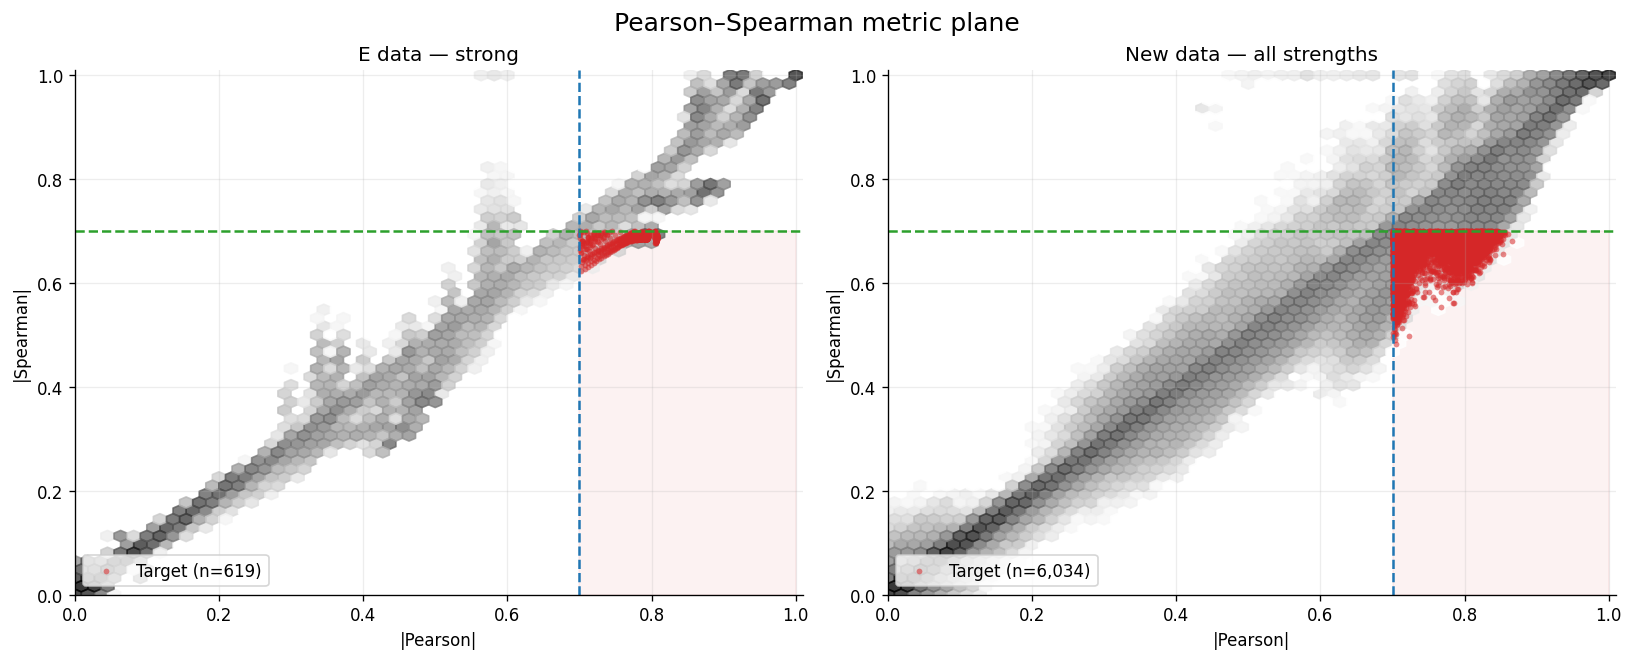

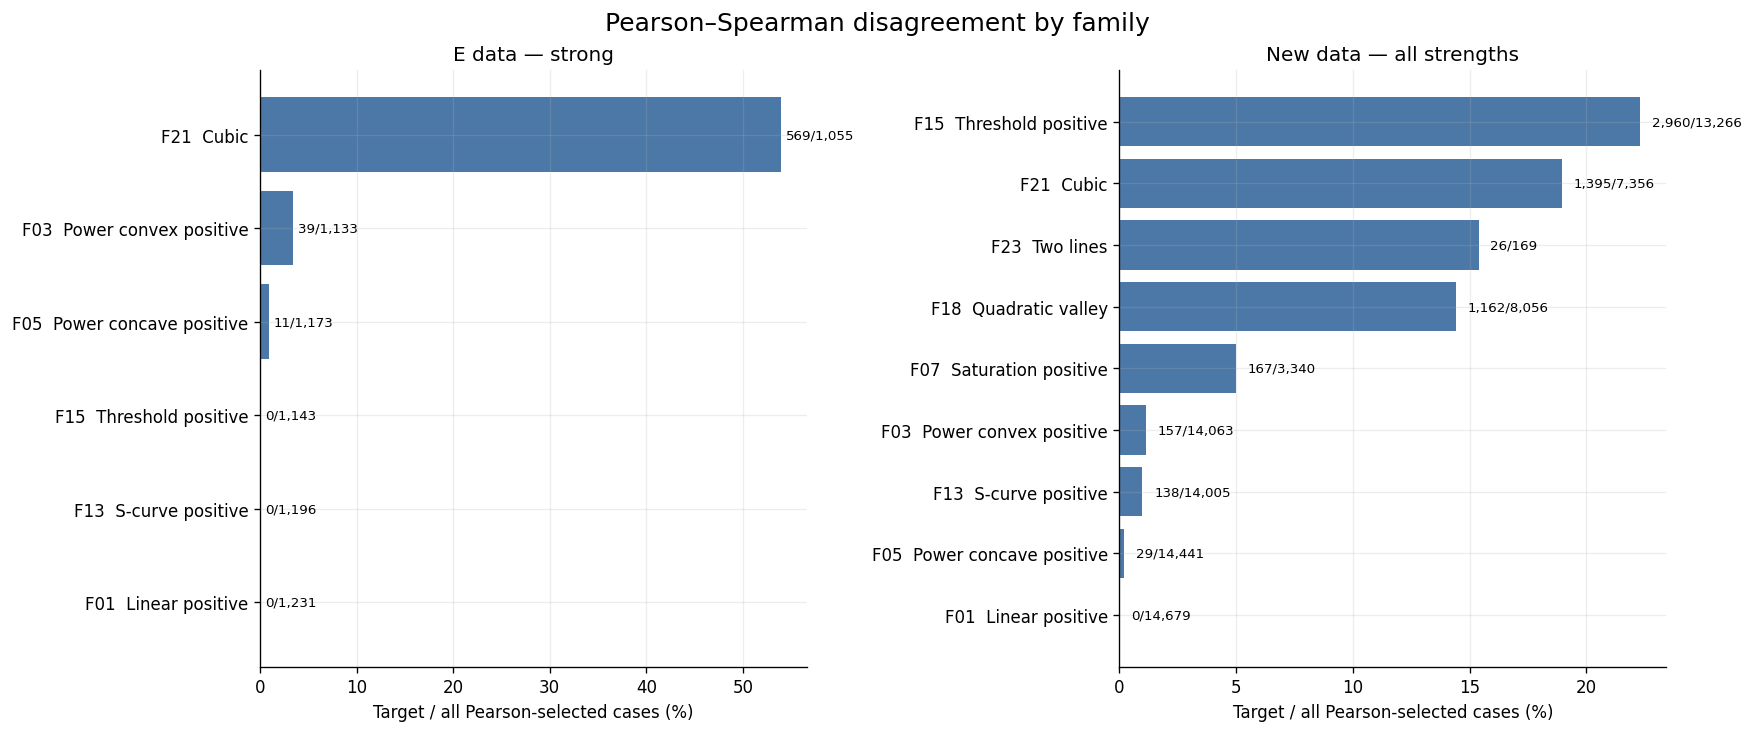

In [5]:
# ============================================================
# Visualize the metric plane and per-family target rates
# ============================================================
fig, axes = plt.subplots(1, len(datasets), figsize=(13.5, 5.4), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, (dataset_name, data) in zip(axes, datasets.items()):
    ax.hexbin(
        data['pearson_value'], data['spearman_value'], gridsize=55,
        mincnt=1, cmap='Greys', bins='log', alpha=0.78,
    )
    target = data[data['discordant']]
    ax.scatter(
        target['pearson_value'], target['spearman_value'], s=12,
        c='#d62728', alpha=0.55, linewidths=0, label=f'Target (n={len(target):,})',
    )
    ax.axvline(PEARSON_THRESHOLD, color='#1f77b4', linestyle='--', linewidth=1.5)
    ax.axhline(SPEARMAN_THRESHOLD, color='#2ca02c', linestyle='--', linewidth=1.5)
    ax.fill_between(
        [PEARSON_THRESHOLD, 1.0], 0, SPEARMAN_THRESHOLD,
        color='#d62728', alpha=0.06, zorder=0,
    )
    ax.set_xlim(0, 1.01)
    ax.set_ylim(0, 1.01)
    ax.set_xlabel('|Pearson|')
    ax.set_ylabel('|Spearman|')
    ax.set_title(dataset_name)
    ax.legend(loc='lower left', frameon=True)
fig.suptitle('Pearson–Spearman metric plane', fontsize=15)
fig.savefig(OUT_DIR / 'pearson_spearman_metric_plane.png', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, len(datasets), figsize=(14.5, 6.0), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, (dataset_name, family) in zip(axes, family_numeric_tables.items()):
    plotted = family[family['pearson_selected'] > 0].sort_values(
        'discordant_within_pearson_percent', ascending=True
    )
    labels = plotted['family_id'] + '  ' + plotted['family_name']
    bars = ax.barh(labels, plotted['discordant_within_pearson_percent'], color='#4c78a8')
    for bar, n, d in zip(bars, plotted['discordant'], plotted['pearson_selected']):
        ax.text(
            bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{int(n):,}/{int(d):,}', va='center', fontsize=8,
        )
    ax.set_xlabel('Target / all Pearson-selected cases (%)')
    ax.set_title(dataset_name)
    ax.set_xlim(left=0)
fig.suptitle('Pearson–Spearman disagreement by family', fontsize=15)
fig.savefig(OUT_DIR / 'family_disagreement_rates.png', bbox_inches='tight')
plt.show()

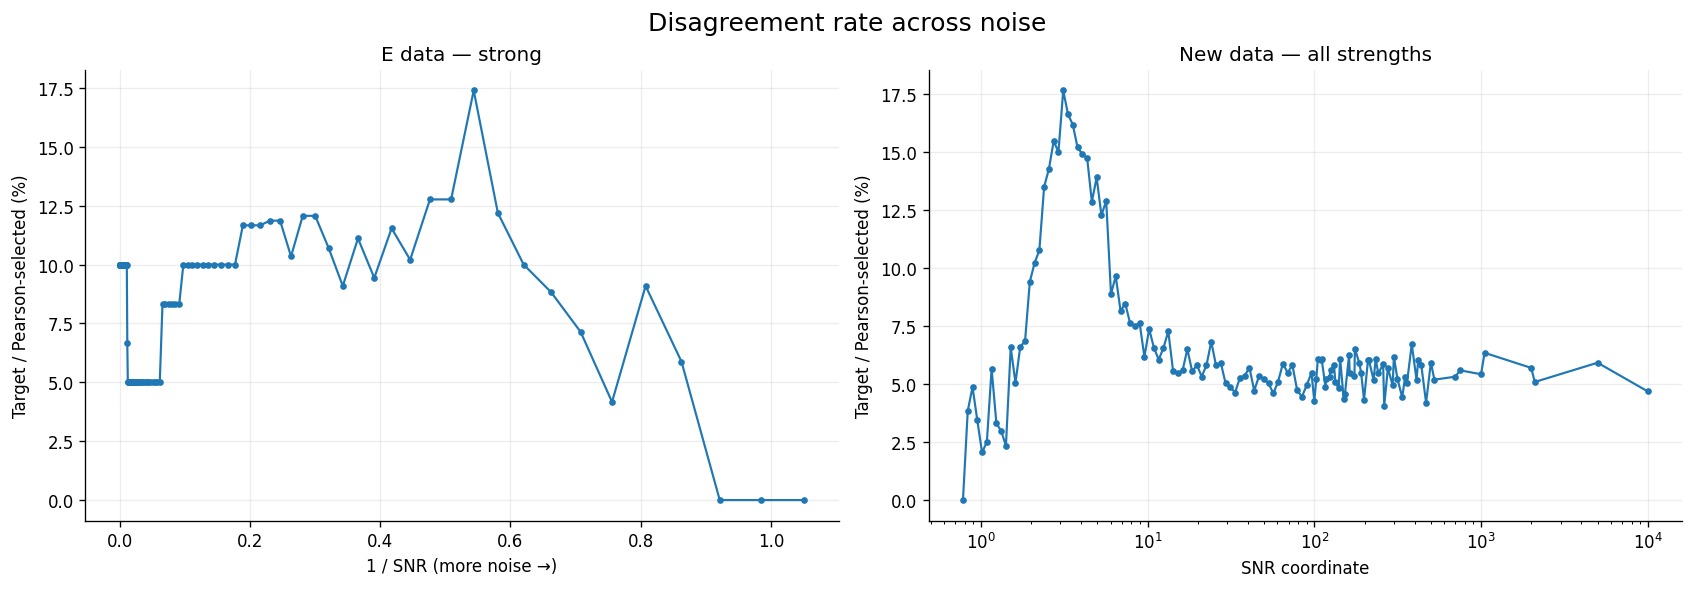

In [6]:
# ============================================================
# Target rate across the dataset-native noise coordinate
# ============================================================
fig, axes = plt.subplots(1, len(datasets), figsize=(14, 4.8), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, (dataset_name, data) in zip(axes, datasets.items()):
    selected = data[data['pearson_selected'] & data['noise_value'].notna()].copy()
    noise = selected.groupby('noise_value', observed=True).agg(
        denominator=('case_id', 'size'), target=('discordant', 'sum')
    ).reset_index()
    noise = noise[noise['denominator'] >= 5]
    noise['rate'] = 100 * noise['target'] / noise['denominator']
    ax.plot(noise['noise_value'], noise['rate'], marker='o', markersize=3, linewidth=1.3)
    if (noise['noise_value'] > 0).all() and noise['noise_value'].nunique() > 5:
        ax.set_xscale('log')
    ax.set_xlabel(DATASET_SPECS[dataset_name]['noise_label'])
    ax.set_ylabel('Target / Pearson-selected (%)')
    ax.set_title(dataset_name)
fig.suptitle('Disagreement rate across noise', fontsize=15)
fig.savefig(OUT_DIR / 'disagreement_rate_by_noise.png', bbox_inches='tight')
plt.show()

## Representative raw scatterplots

Within every family containing target cases, examples are selected near the 10th, 50th, and 90th percentiles of $|Pearson|-|Spearman|$. The new-data NPZ is several gigabytes when decompressed, so the loader streams only the selected rows instead of loading the full array.

In [7]:
# ============================================================
# Low-memory selected-row loader for NPZ members
# ============================================================
def read_selected_rows_from_npz(npz_path, key, indices):
    indices = np.unique(np.asarray(indices, dtype=np.int64))
    if len(indices) == 0:
        return {}
    output = {}
    with zipfile.ZipFile(npz_path) as archive, archive.open(f'{key}.npy') as stream:
        version = np.lib.format.read_magic(stream)
        shape, fortran_order, dtype = np.lib.format._read_array_header(stream, version)
        if fortran_order or len(shape) != 2:
            raise ValueError(f'Expected a C-order 2D array, found shape={shape}.')
        if indices.min() < 0 or indices.max() >= shape[0]:
            raise IndexError(f'Selected row is outside NPZ array with {shape[0]:,} rows.')
        row_bytes = int(np.prod(shape[1:])) * np.dtype(dtype).itemsize
        previous = -1
        for index in indices:
            skip = (int(index) - previous - 1) * row_bytes
            if skip:
                stream.seek(skip, 1)
            buffer = stream.read(row_bytes)
            if len(buffer) != row_bytes:
                raise EOFError(f'Could not read row {index} from {npz_path}.')
            output[int(index)] = np.frombuffer(buffer, dtype=dtype).copy().reshape(shape[1:])
            previous = int(index)
    return output

def select_gap_quantile_examples(data, per_family=3, max_total=21):
    target = data[data['discordant']].copy()
    selected_rows = []
    quantiles = np.linspace(0.10, 0.90, per_family) if per_family > 1 else np.array([0.50])
    for _, group in target.groupby('family_id', sort=True):
        group = group.sort_values(['correlation_gap', 'case_id'])
        gaps = group['correlation_gap'].to_numpy()
        used = set()
        for q in quantiles:
            goal = float(np.quantile(gaps, q))
            order = np.argsort(np.abs(gaps - goal))
            choice = next((int(i) for i in order if int(i) not in used), int(order[0]))
            used.add(choice)
            selected_rows.append(group.iloc[choice])
    if not selected_rows:
        return target.iloc[0:0].copy()
    selected = pd.DataFrame(selected_rows)
    return selected.sort_values(['family_id', 'correlation_gap']).head(max_total).copy()

E data — strong: streaming 9 selected x/y rows from scatter_points.npz ...


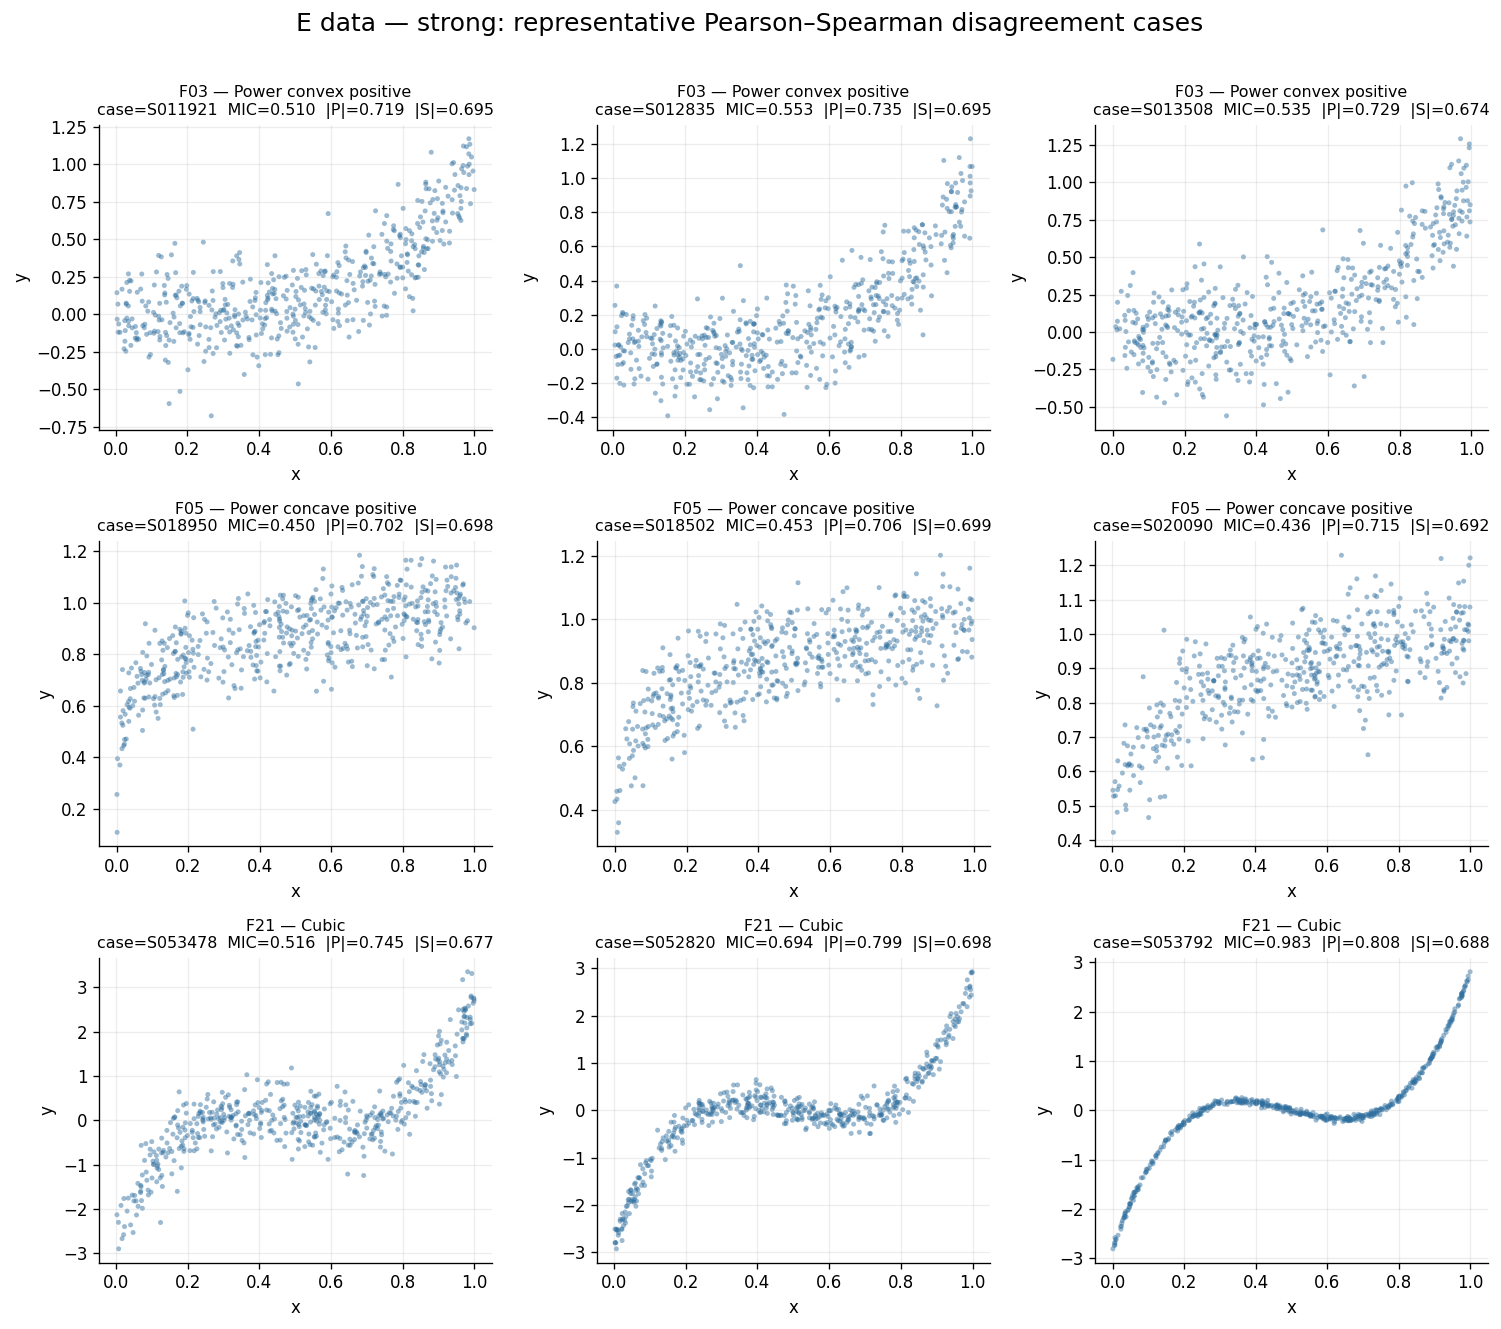

New data — all strengths: streaming 21 selected x/y rows from scatter_points.npz ...


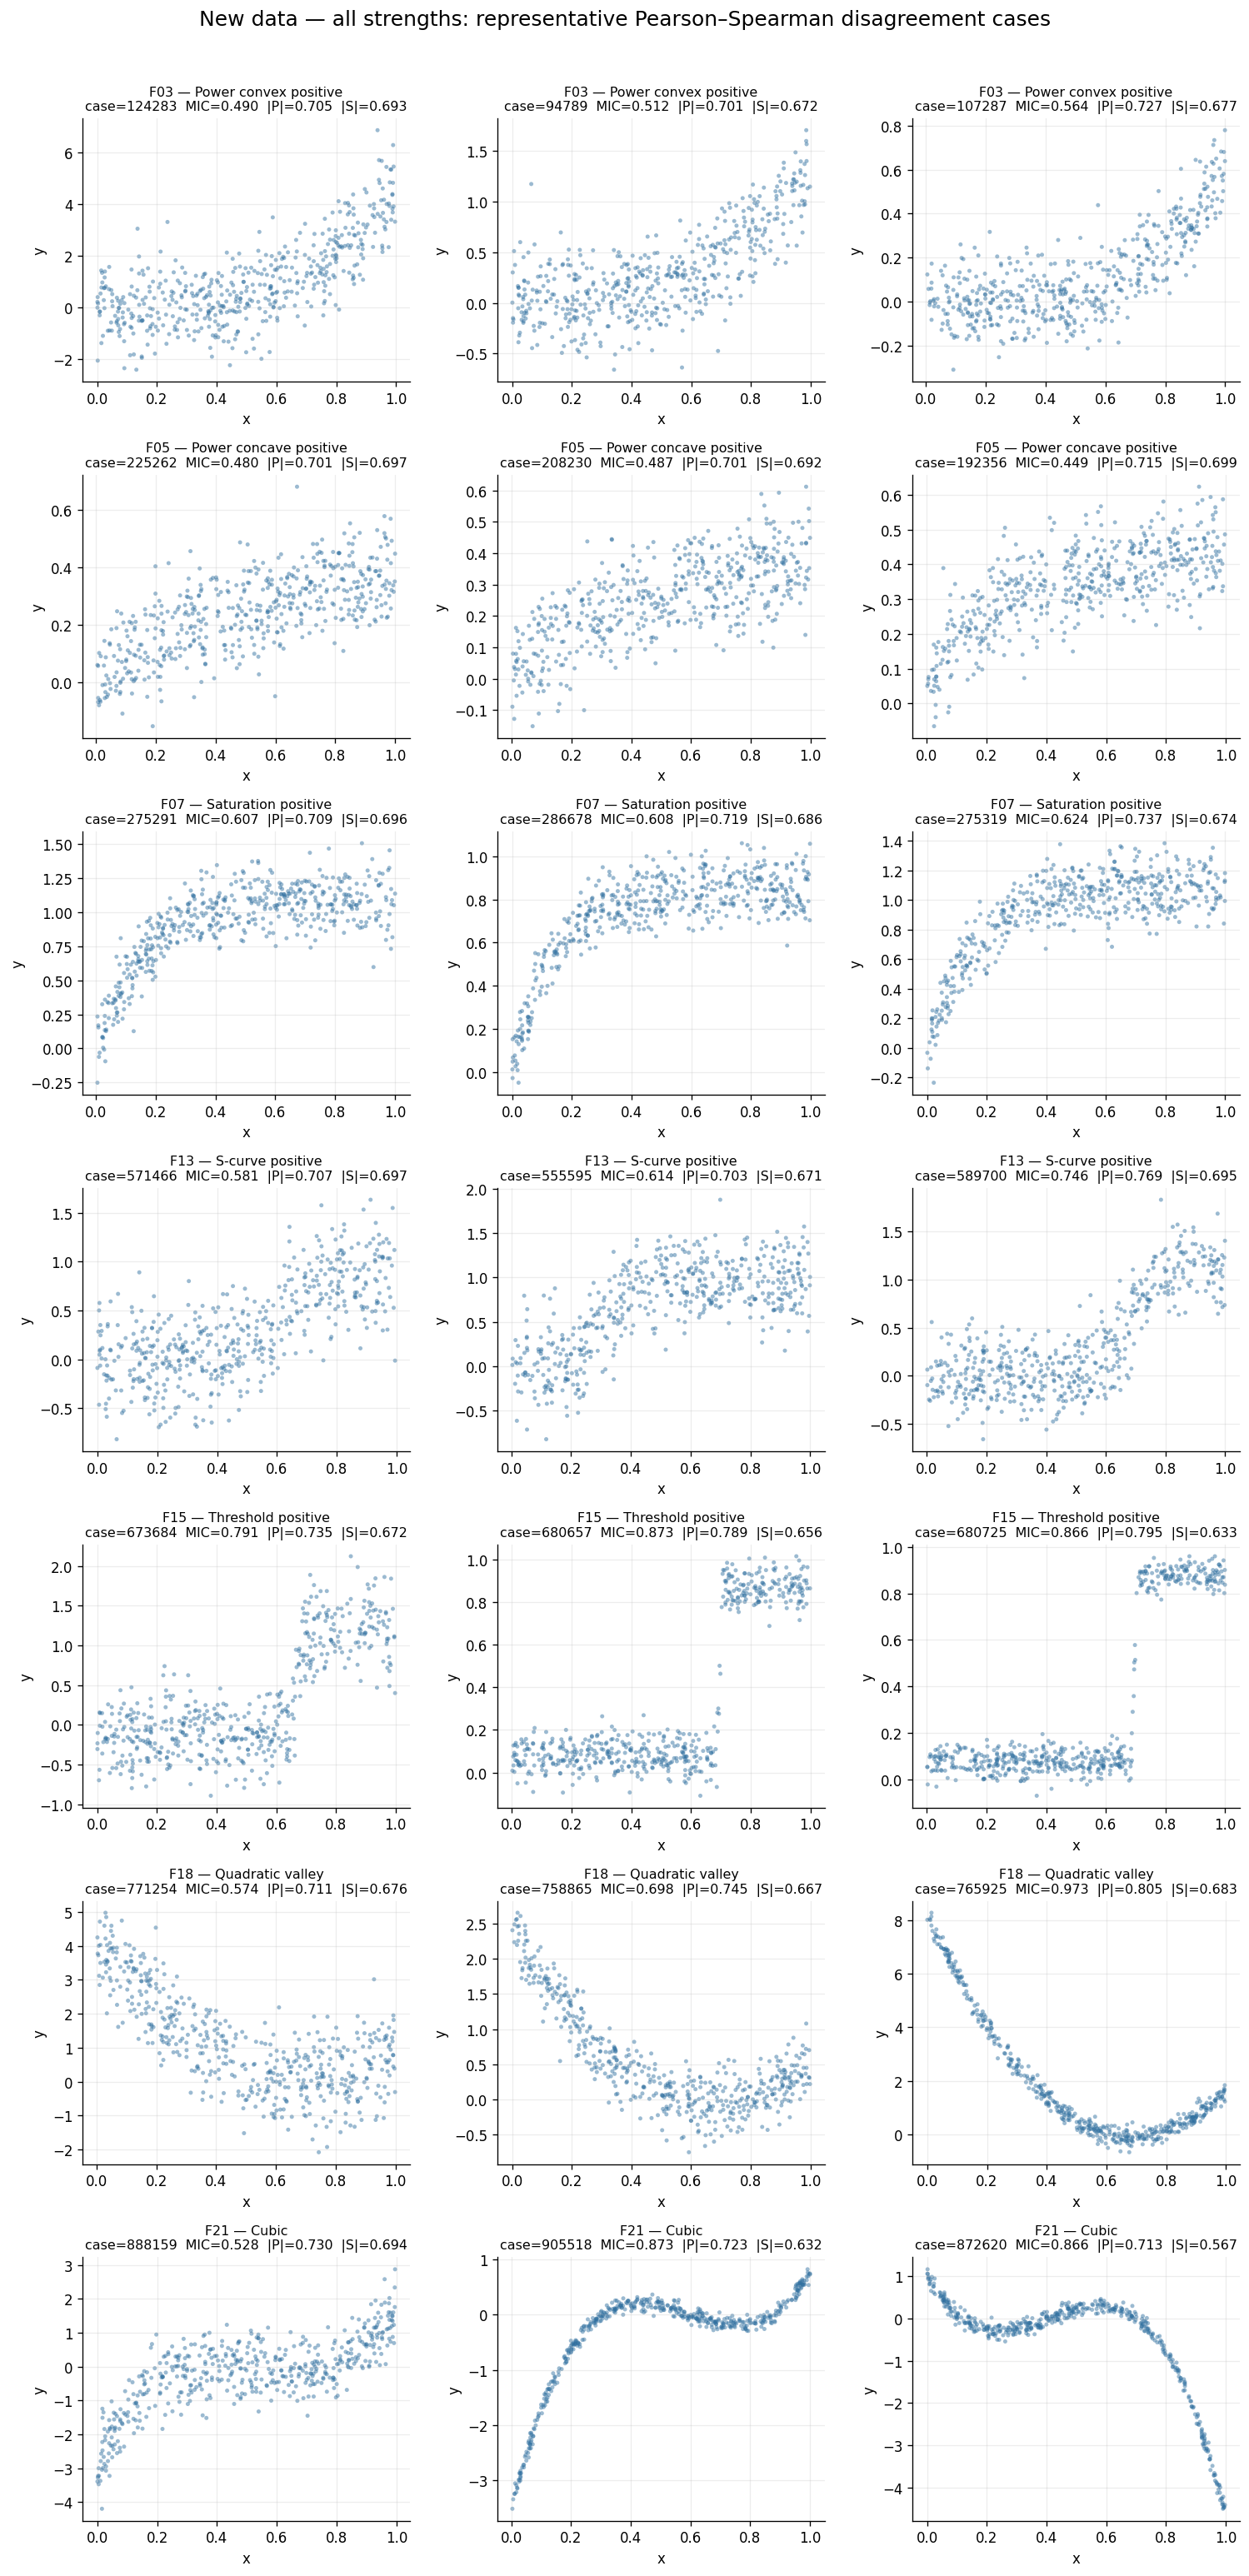

Saved outputs to: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/S3_1_pearson_spearman_disagreement


In [8]:
# ============================================================
# Draw and save representative raw scatterplots
# ============================================================
if MAKE_RAW_GALLERY:
    for dataset_name, data in datasets.items():
        examples = select_gap_quantile_examples(
            data, RAW_EXAMPLES_PER_FAMILY, MAX_RAW_EXAMPLES_PER_DATASET
        )
        if examples.empty:
            print(dataset_name, ': no target cases.')
            continue

        indices = examples['scatter_point_index'].astype(int).to_numpy()
        point_path = DATASET_SPECS[dataset_name]['points']
        print(f'{dataset_name}: streaming {len(indices)} selected x/y rows from {point_path.name} ...')
        x_rows = read_selected_rows_from_npz(point_path, 'x', indices)
        y_rows = read_selected_rows_from_npz(point_path, 'y', indices)

        ncols = 3
        nrows = math.ceil(len(examples) / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(12.6, 3.75*nrows), squeeze=False)
        for ax, (_, row) in zip(axes.flat, examples.iterrows()):
            index = int(row['scatter_point_index'])
            x = x_rows[index]
            y = y_rows[index]
            valid = np.isfinite(x) & np.isfinite(y)
            ax.scatter(x[valid], y[valid], s=9, alpha=0.48, color='#2f6f9f', edgecolors='none')
            ax.set_title(
                f"{row['family_id']} — {row['family_name']}\n"
                f"case={row['case_id']}  MIC={row['MIC']:.3f}  "
                f"|P|={row['abs_pearson']:.3f}  |S|={row['abs_spearman']:.3f}",
                fontsize=9.5,
            )
            ax.set_xlabel('x')
            ax.set_ylabel('y')
        for ax in axes.flat[len(examples):]:
            ax.axis('off')
        fig.suptitle(f'{dataset_name}: representative Pearson–Spearman disagreement cases', fontsize=15)
        fig.tight_layout(rect=[0, 0, 1, 0.97])
        safe_name = dataset_name.lower().replace(' ', '_').replace('—', '').replace('__', '_')
        fig.savefig(OUT_DIR / f'{safe_name}_raw_scatter_examples.png', bbox_inches='tight')
        plt.show()

print('Saved outputs to:', OUT_DIR)

## MIC > 0.8 + Pearson > 0.7 + Spearman < 0.7 scatter gallery

Cases that pass Gate 1 (strong global MIC) but have discordant Pearson/Spearman — these are the ones that would enter Gate 2 as **Complex** instead of Simple.


E data — strong: 316 cases with MIC>0.8 + |P|>0.7 + |S|<0.7
family_id
F21    316
  Streaming 3 scatter rows from scatter_points.npz ...


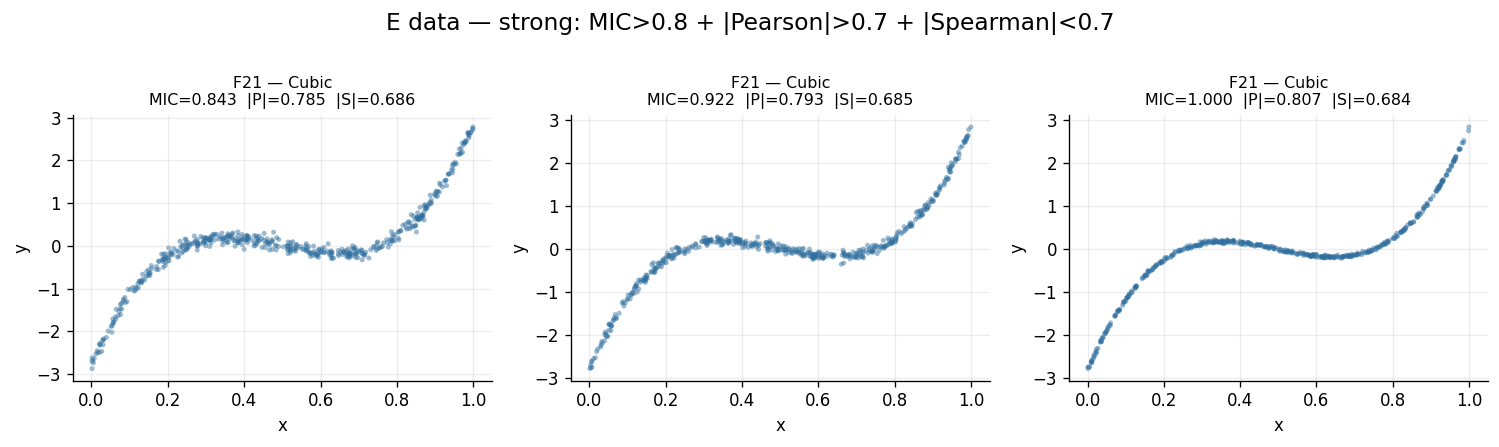


New data — all strengths: 3,878 cases with MIC>0.8 + |P|>0.7 + |S|<0.7
family_id
F13       2
F15    2682
F18     406
F21     786
F23       2
  Streaming 15 scatter rows from scatter_points.npz ...


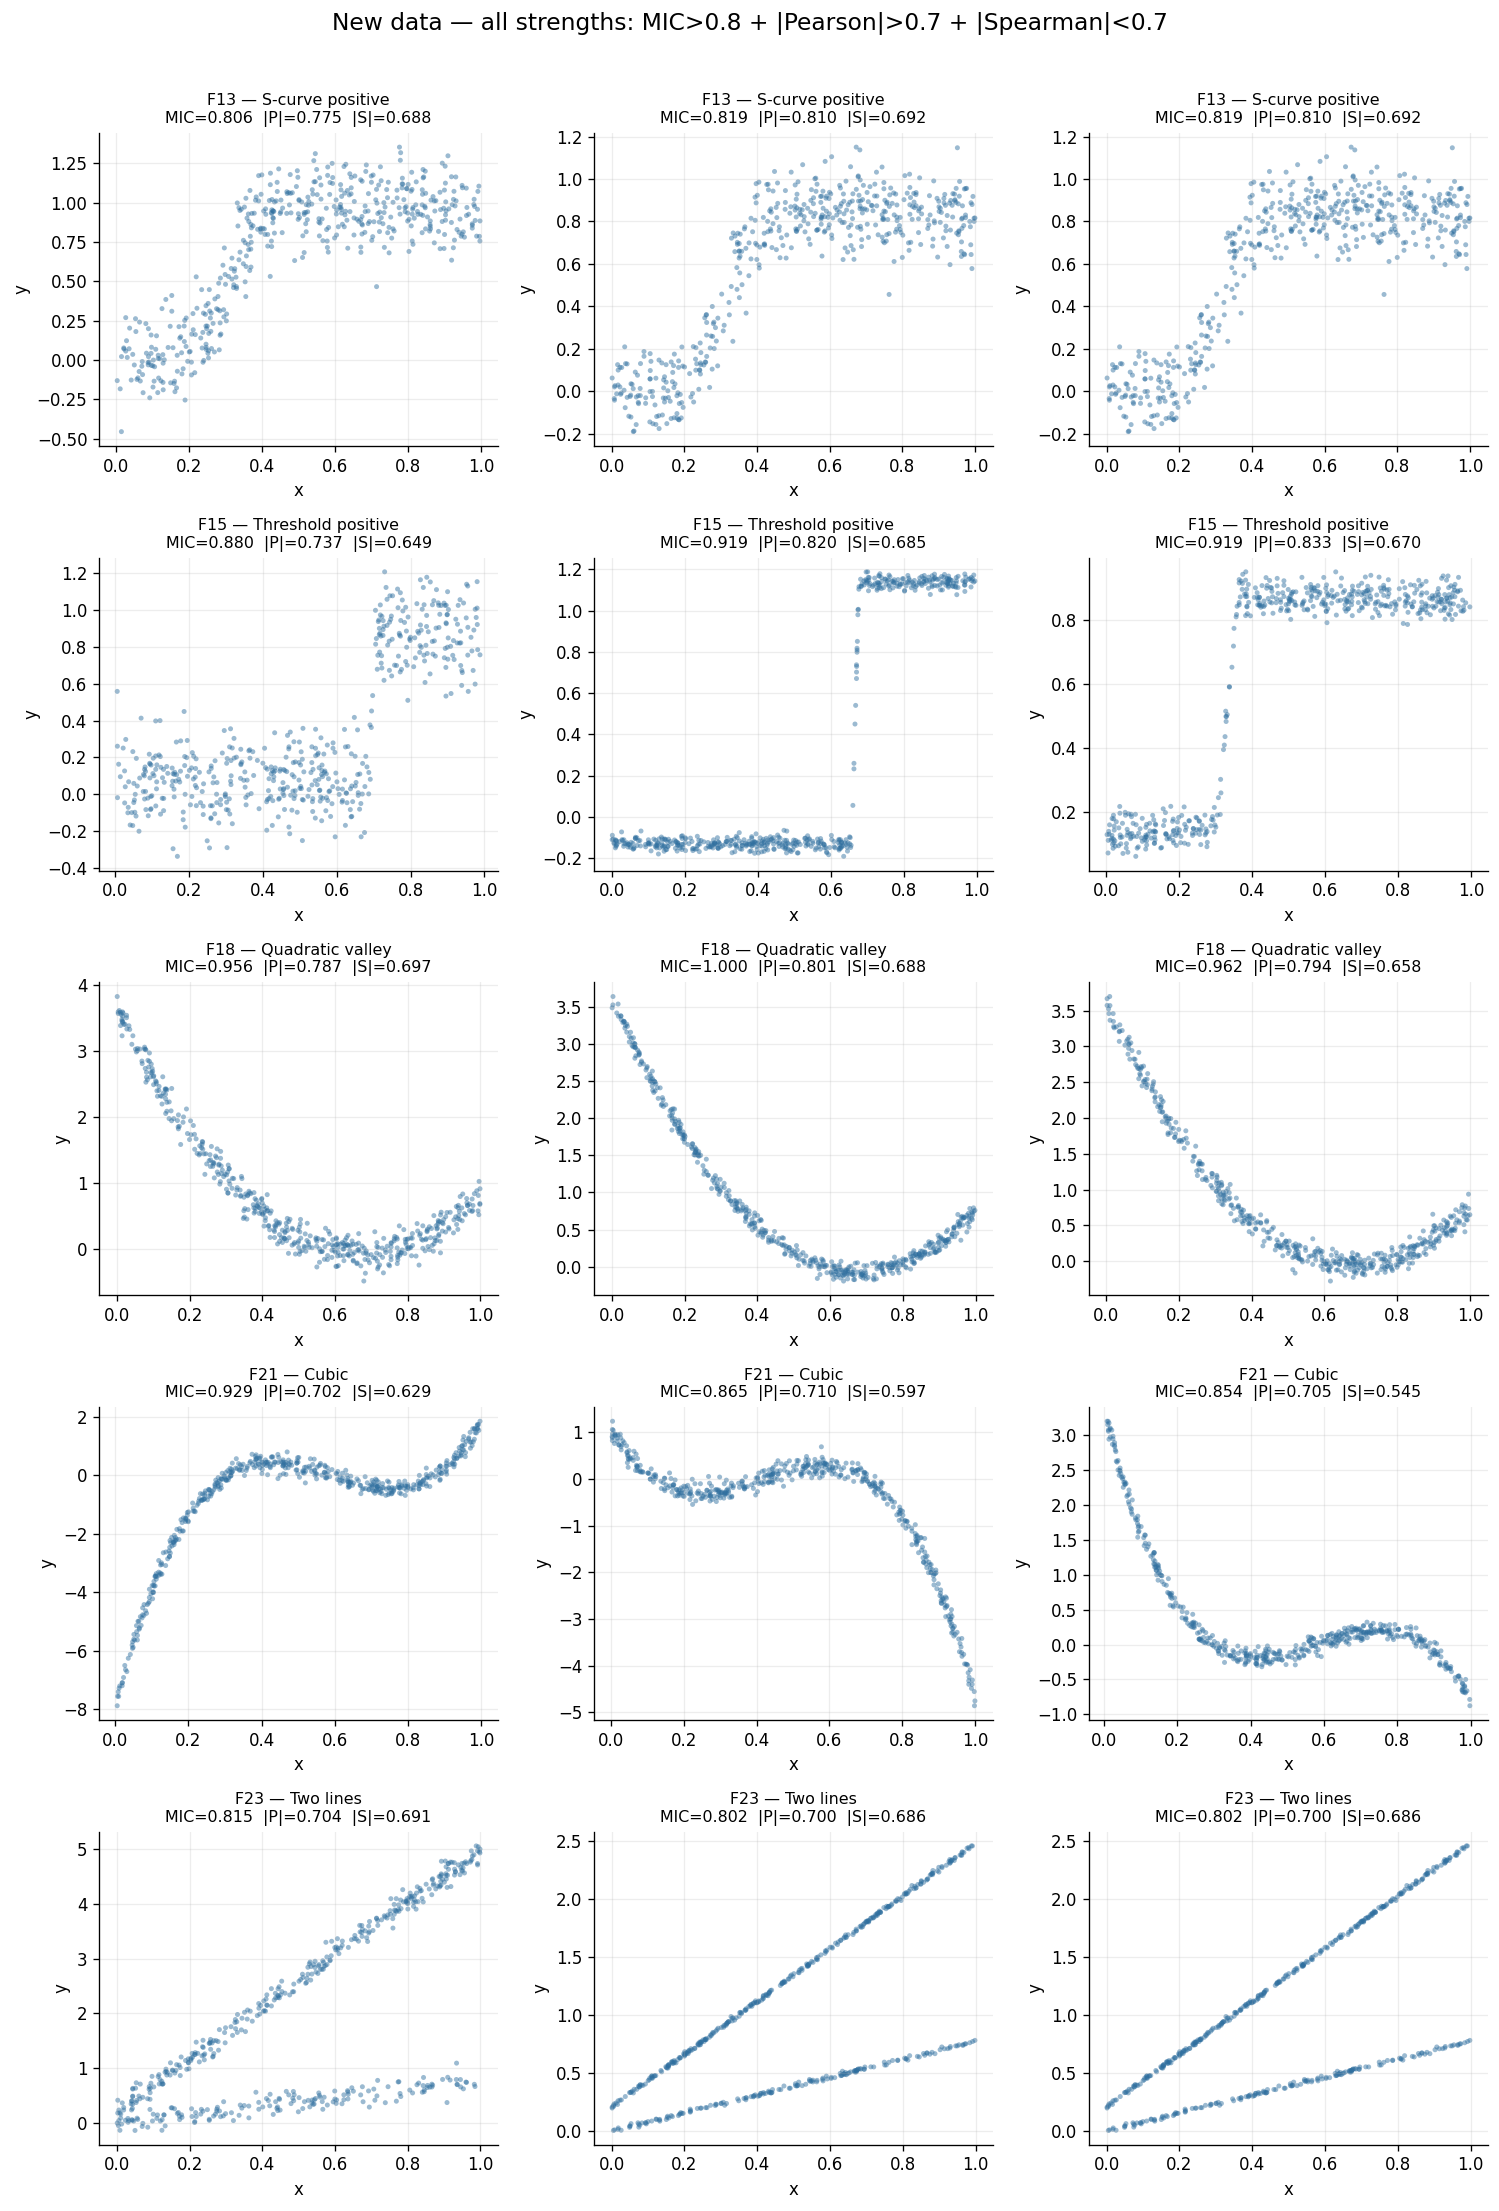

In [9]:
# MIC > 0.8 + |Pearson| > 0.7 + |Spearman| < 0.7: scatter plot gallery
for dataset_name, data in datasets.items():
    subset = data[
        (data['MIC'] >= 0.8)
        & (data['abs_pearson'] > 0.7)
        & (data['abs_spearman'] < 0.7)
    ].copy()
    if subset.empty:
        print(f'{dataset_name}: no cases match MIC>0.8 + |P|>0.7 + |S|<0.7')
        continue

    print(f'\n{dataset_name}: {len(subset):,} cases with MIC>0.8 + |P|>0.7 + |S|<0.7')
    print(subset.groupby('family_id').size().to_string())

    # Pick up to 3 examples per family (low/mid/high gap)
    examples = select_gap_quantile_examples(
        subset.assign(discordant=True),
        per_family=3, max_total=30
    )
    if examples.empty:
        continue

    indices = examples['scatter_point_index'].astype(int).to_numpy()
    point_path = DATASET_SPECS[dataset_name]['points']
    print(f'  Streaming {len(indices)} scatter rows from {point_path.name} ...')
    x_rows = read_selected_rows_from_npz(point_path, 'x', indices)
    y_rows = read_selected_rows_from_npz(point_path, 'y', indices)

    ncols = 3
    nrows = math.ceil(len(examples) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12.6, 3.75 * nrows), squeeze=False)
    for ax, (_, row) in zip(axes.flat, examples.iterrows()):
        index = int(row['scatter_point_index'])
        x = x_rows[index]
        y = y_rows[index]
        valid = np.isfinite(x) & np.isfinite(y)
        ax.scatter(x[valid], y[valid], s=9, alpha=0.48, color='#2f6f9f', edgecolors='none')
        ax.set_title(
            f"{row['family_id']} — {row['family_name']}\n"
            f"MIC={row['MIC']:.3f}  |P|={row['abs_pearson']:.3f}  |S|={row['abs_spearman']:.3f}",
            fontsize=9.5,
        )
        ax.set_xlabel('x')
        ax.set_ylabel('y')
    for ax in axes.flat[len(examples):]:
        ax.axis('off')
    fig.suptitle(
        f'{dataset_name}: MIC>0.8 + |Pearson|>0.7 + |Spearman|<0.7',
        fontsize=14
    )
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    safe_name = dataset_name.lower().replace(' ', '_').replace('—', '').replace('__', '_')
    fig.savefig(OUT_DIR / f'{safe_name}_mic_discordant_gallery.png', bbox_inches='tight')
    plt.show()

## Interpretation

A high Pearson correlation with a lower Spearman correlation is not necessarily a metric failure. It indicates strong global covariance or level separation without equally consistent rank ordering. Typical causes include direction reversals, plateaus/ties, threshold-like transitions, and asymmetric non-monotonic relationships. Requiring both correlation metrics in the Simple gate prevents these cases from being treated as unambiguously monotonic.